<a href="https://colab.research.google.com/github/alkhurayjah/Clustering_Mini_Project/blob/main/Clustering_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

import matplotlib.pyplot as plt



In [87]:
# Load dataset
df = pd.read_csv("Mall_Customers.csv")
#file_path = r"C:\Users\faisa\Downloads\Mall_Customers.csv"
#df = pd.read_csv(file_path)

# Show first rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [88]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [89]:
# Describe
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [90]:
#  Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [91]:
# : Check missing values
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


CustomerID is just an identifier and does not contribute to clustering patterns.

In [92]:
#  Drop irrelevant columns

df = df.drop(columns=["CustomerID"])

In [93]:
# Encode Gender

df = pd.get_dummies(df, columns=["Gender"], drop_first=True, dtype=int)

In [94]:
# Select features
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

# Apply scaling
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

# Preview
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,-1.424569,-1.738999,-0.434801,1
1,-1.281035,-1.738999,1.195704,1
2,-1.352802,-1.700830,-1.715913,0
3,-1.137502,-1.700830,1.040418,0
4,-0.563369,-1.662660,-0.395980,0


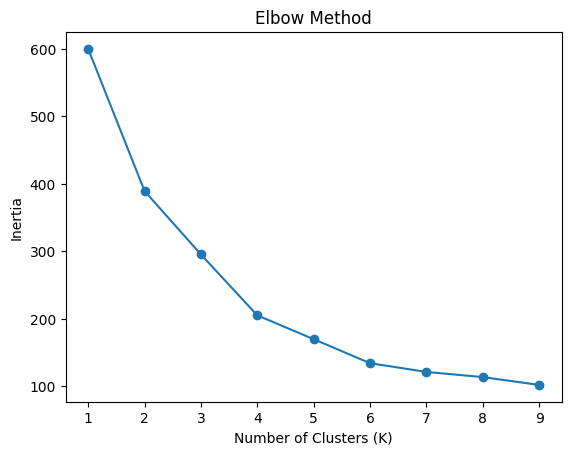

In [95]:
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df[features])
    inertia.append(kmeans.inertia_)

# Plot Elbow
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [96]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(df[features])

df["Cluster_KMeans"] = clusters

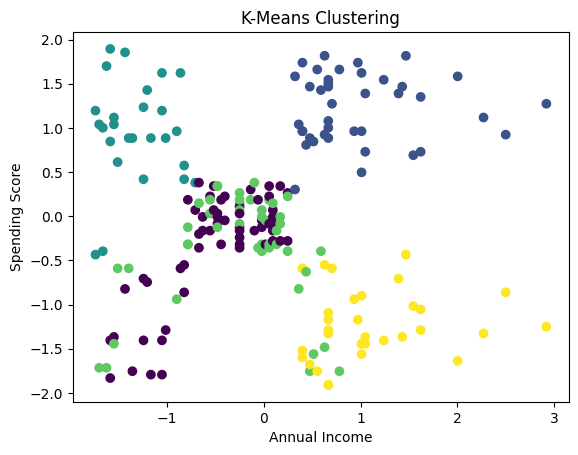

In [97]:
plt.scatter(df["Annual Income (k$)"],
            df["Spending Score (1-100)"],
            c=df["Cluster_KMeans"],
            cmap='viridis')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.show()

### DBSCAN

In [98]:
db = DBSCAN(eps=0.4, min_samples=4)
clusters_db = db.fit_predict(df[features])
df['Cluster_DBScan'] = clusters_db

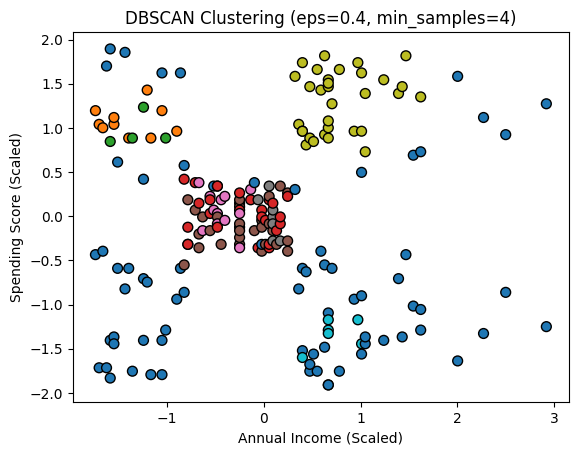

In [99]:
# DBSCAN Plot
db_clusters = df['Cluster_DBScan']
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"],
            c=db_clusters, cmap='tab10', s=50, edgecolors='k')
plt.title(f"DBSCAN Clustering (eps=0.4, min_samples=4)")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")

plt.show()

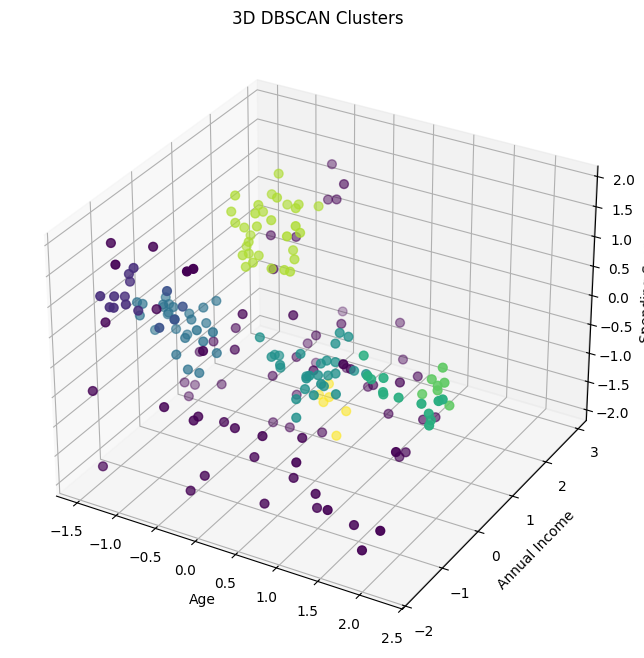

In [100]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df["Age"], df["Annual Income (k$)"], df["Spending Score (1-100)"],
           c=df["Cluster_DBScan"], cmap='viridis', s=40)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income")
ax.set_zlabel("Spending Score")
plt.title("3D DBSCAN Clusters")
plt.show()

###Hierarchical

In [101]:
from sklearn.cluster import AgglomerativeClustering

# Apply Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
clusters_hc = hc.fit_predict(df[features])

df['Cluster_HC'] = clusters_hc

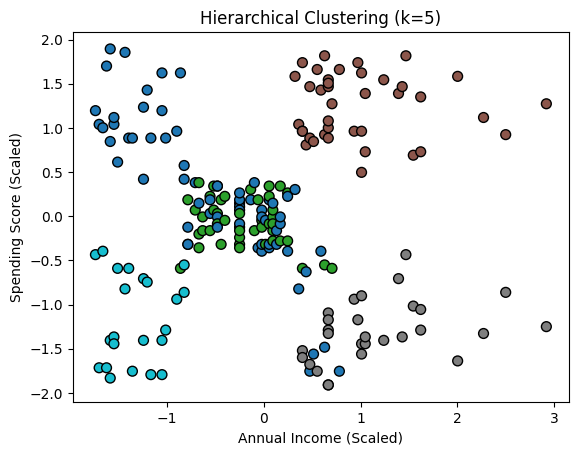

In [102]:
hc_clusters = df['Cluster_HC']

plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"],
            c=hc_clusters, cmap='tab10', s=50, edgecolors='k')

plt.title("Hierarchical Clustering (k=5)")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")

plt.show()

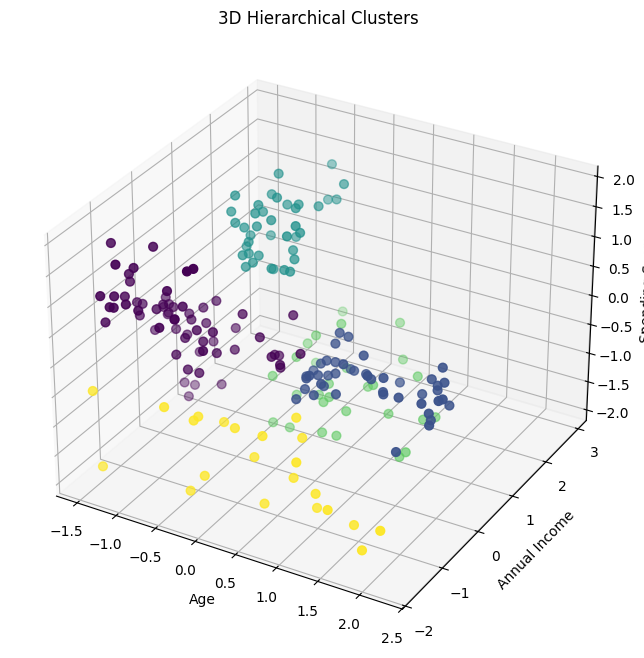

In [103]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df["Age"], df["Annual Income (k$)"], df["Spending Score (1-100)"],
           c=df["Cluster_HC"], cmap='viridis', s=40)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income")
ax.set_zlabel("Spending Score")

plt.title("3D Hierarchical Clusters")
plt.show()

Clustering Comparison Results
K-Means      | Clusters: 5 | Silhouette Score: 0.4085
Hierarchical | Clusters: 5 | Silhouette Score: 0.3900
DBSCAN       | Clusters: 8 | Noise: 73 | Silhouette Score: 0.4585


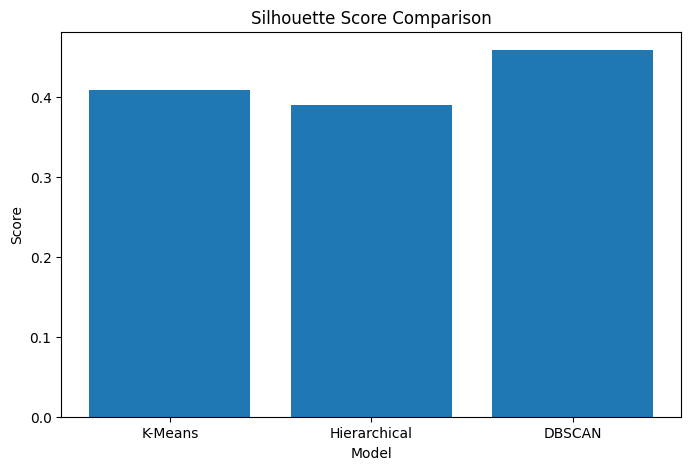

In [105]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Data scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Silhouette scores
score_kmeans = silhouette_score(X_scaled, df['Cluster_KMeans'])
score_hc = silhouette_score(X_scaled, df['Cluster_HC'])

mask = df['Cluster_DBScan'] != -1
score_dbscan = silhouette_score(X_scaled[mask], df['Cluster_DBScan'][mask])

# Print results
print("=" * 50)
print("Clustering Comparison Results")
print("=" * 50)

print(f"K-Means      | Clusters: {len(set(df['Cluster_KMeans']))} | Silhouette Score: {score_kmeans:.4f}")
print(f"Hierarchical | Clusters: {len(set(df['Cluster_HC']))} | Silhouette Score: {score_hc:.4f}")
print(f"DBSCAN       | Clusters: {len(set(df['Cluster_DBScan'])) - 1} | Noise: {list(df['Cluster_DBScan']).count(-1)} | Silhouette Score: {score_dbscan:.4f}")

print("=" * 50)

# Visualization
models = ['K-Means', 'Hierarchical', 'DBSCAN']
scores = [score_kmeans, score_hc, score_dbscan]

plt.figure(figsize=(8, 5))
plt.bar(models, scores)

plt.title("Silhouette Score Comparison")
plt.xlabel("Model")
plt.ylabel("Score")

plt.show()

## Clustering Comparison Conclusion

After applying K-Means, Hierarchical Clustering, and DBSCAN, the models were evaluated using the Silhouette Score.

- **K-Means** achieved the highest silhouette score, indicating well-separated and compact clusters. The Elbow Method was used to determine the optimal number of clusters.
- **Hierarchical Clustering** produced comparable results, but it is more computationally expensive and requires defining the number of clusters.
- **DBSCAN** was effective in detecting noise (outliers), but its silhouette score was lower due to excluding noise points.

#Final Decision:
K-Means is the best-performing algorithm for this dataset in terms of clustering quality, while DBSCAN is useful for identifying outliers.